In [1]:
from pathlib import Path
from datetime import datetime, timedelta, date
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis, align2img
from gulp2p.preproc import utils, behavior
from gulp2p.preproc.tiff import Tiff
from gulp2p.config import BHV_DATA_RAW_DIR

### Logging config

In [2]:
log_level = logging.INFO    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

### User Settings

In [3]:
tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS")
bhv_folder = BHV_DATA_RAW_DIR
PURGE_TIFF_METADATA = False

## Compare tiff and bhv creation times

In [4]:
# do this for all bhv and tiffs in kerstins mimms folder
# Ignore time differences greater than 1 maybe 2 minutes (?)
# Need a way to synce up tiff and bhv files

In [5]:
def find_bhv_path_from_tiff(tiff_timestamp, bhv_folder=None):
    if bhv_folder is None:
        bhv_folder = Path(r"Z:\Live Fly Imaging data\unity\raw data")
    min_diff = None
    min_file = None
    for path in bhv_folder.rglob("*"):
        if not path.is_file():
            continue
        try:
            file_timestamp = utils.get_timestamp_from_string(path.name)
        except:
            continue

        time_diff = file_timestamp - tiff_timestamp
        if min_diff is None:
            min_diff = time_diff
            min_file = path
        if abs(time_diff) < abs(min_diff):
            min_diff = time_diff
            min_file = path
    return min_file, min_diff



In [6]:
tiff_paths = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    if path.name in [p.name for p in tiff_paths]:
        continue
    tiff_paths.append(path)

df_dicts = []
for tiff_path in tiff_paths:
    tiff = Tiff(tiff_path)
    if PURGE_TIFF_METADATA:
        try:
            if hasattr(tiff, 'metadata'):
                del tiff.metadata
                logger.debug(f"Deleted metadata cache of {tiff_path.name}")
        except AttributeError:
            logger.debug(f"Couldn't delete metadata cache of {tiff_path.name}")
            pass
    tiff_date = tiff.metadata['date']
    tiff_timestamp = tiff_date.timestamp()
    bhv_path, min_diff = find_bhv_path_from_tiff(tiff_timestamp)
    bhv_date = datetime.fromtimestamp(utils.get_timestamp_from_string(bhv_path.name))
    df_dicts.append({"tiff_date": tiff_date,
                     "bhv_date": bhv_date})
dates_df = pd.DataFrame(df_dicts)

dates_df['diff'] = dates_df['tiff_date'] - dates_df['bhv_date']

In [7]:
dates_df.head()

,tiff_date,bhv_date,diff
0,2023-11-09 14:56:55.361745,2023-11-09 15:07:44,-1 days +23:49:11.361745
1,2023-11-09 15:11:52.887970,2023-11-09 15:10:08,0 days 00:01:44.887970
2,2023-11-09 15:13:49.404712,2023-11-09 15:10:08,0 days 00:03:41.404712
3,2023-11-09 15:19:08.889896,2023-11-09 15:21:44,-1 days +23:57:24.889896
4,2023-11-09 15:21:45.755689,2023-11-09 15:21:44,0 days 00:00:01.755689


In [8]:
# tiff is created about 33 seconds after bhv file
dates_df.describe()

,tiff_date,bhv_date,diff
count,242,242,242
mean,2024-02-04 01:24:43.400723712,2024-02-04 01:25:51.074380032,-1 days +23:58:52.326343484
min,2023-11-09 14:56:55.361745,2023-11-09 15:07:44,-1 days +18:40:50.162206
25%,2023-12-06 11:10:11.850355712,2023-12-06 11:09:54.249999872,0 days 00:00:05.988007750
50%,2024-01-17 10:55:43.035245568,2024-01-17 10:55:40.500000,0 days 00:00:24.647003500
75%,2024-02-15 11:33:12.486952448,2024-02-15 11:31:44,0 days 00:01:08.591324500
max,2024-07-08 12:34:29.201081,2024-07-08 12:33:45,0 days 00:11:33.426860
std,NaN,NaN,0 days 00:21:15.037647823


In [9]:
dates_df_filtered = dates_df[(dates_df["diff"] < timedelta(minutes=5)) & (dates_df["diff"] > timedelta(minutes=-5))]

In [10]:
dates_df_filtered.describe()

,tiff_date,bhv_date,diff
count,232,232,232
mean,2024-02-04 06:29:38.834127104,2024-02-04 06:29:10.142241536,0 days 00:00:28.691885724
min,2023-11-09 15:11:52.887970,2023-11-09 15:10:08,-1 days +23:56:34.093432
25%,2023-12-06 11:21:27.545385984,2023-12-06 11:21:10,0 days 00:00:06.192766250
50%,2024-01-17 10:55:43.035245568,2024-01-17 10:55:40.500000,0 days 00:00:24.647003500
75%,2024-02-15 11:36:59.831446528,2024-02-15 11:35:31.249999872,0 days 00:01:08.403871750
max,2024-07-08 12:34:29.201081,2024-07-08 12:33:45,0 days 00:03:41.404712
std,NaN,NaN,0 days 00:00:48.822871221


In [11]:
dates_df_filtered

,tiff_date,bhv_date,diff
1,2023-11-09 15:11:52.887970,2023-11-09 15:10:08,0 days 00:01:44.887970
2,2023-11-09 15:13:49.404712,2023-11-09 15:10:08,0 days 00:03:41.404712
3,2023-11-09 15:19:08.889896,2023-11-09 15:21:44,-1 days +23:57:24.889896
4,2023-11-09 15:21:45.755689,2023-11-09 15:21:44,0 days 00:00:01.755689
6,2023-11-21 11:45:36.960844,2023-11-21 11:48:54,-1 days +23:56:42.960844
...,...,...,...
237,2024-07-08 12:05:58.045388,2024-07-08 12:05:13,0 days 00:00:45.045388
238,2024-07-08 12:13:37.827949,2024-07-08 12:12:53,0 days 00:00:44.827949
239,2024-07-08 12:20:35.453217,2024-07-08 12:19:51,0 days 00:00:44.453217
240,2024-07-08 12:27:31.105077,2024-07-08 12:26:46,0 days 00:00:45.105077


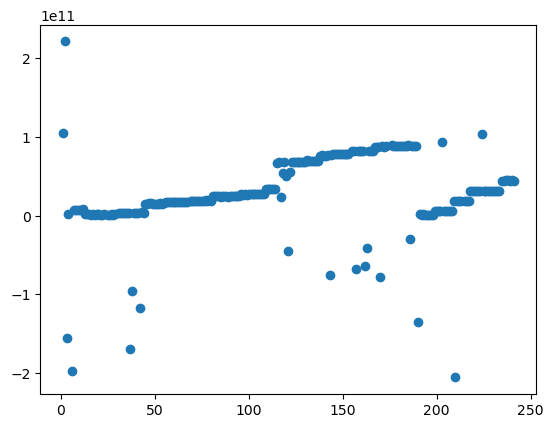

In [12]:
ax = plt.subplot()
ax.scatter(dates_df_filtered.index, dates_df_filtered['diff'])

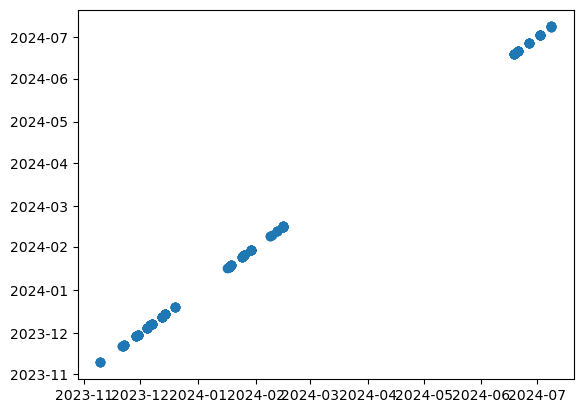

In [13]:
plt.scatter(dates_df_filtered['tiff_date'], dates_df_filtered['bhv_date'])

## Plot recording intervals over an experiment

In [14]:
def convert_interval_units(time_interval):
    # Convert from timestamp to minutes since midnight
    date_day = date.fromtimestamp(time_interval[0])
    new_interval = []
    for timepoint in time_interval:
        midnight_timestamp = datetime.combine(date_day, datetime.min.time()).timestamp()
        seconds_since_midnight = timepoint - midnight_timestamp
        hour_since_midnight = seconds_since_midnight / 60 / 60
        new_interval.append(hour_since_midnight)
    return new_interval

In [15]:
def get_tiff_interval(tiff):
    tiff_start_time = tiff.metadata['date'].timestamp()
    tiff_length = tiff.length
    tiff_interval = (tiff_start_time, tiff_start_time + tiff_length)
    return tiff_interval

def get_bhv_interval(bhv_path):
    bhv_start_time = utils.get_timestamp_from_string(bhv_path.name)
    bhv_length = utils.get_bhv_length(bhv_path)
    if bhv_length is None:
        bhv_length = 0
    bhv_interval = (bhv_start_time, bhv_start_time + bhv_length)
    return bhv_interval

In [44]:
def plot_interval(interval, ax, y, color="C0"):
    ax.plot(interval, [y,y], c=color, marker='o', ms=2)

def plot_intervals(intervals, ax, y, color="C0", dodge=0.2, height=4):
    for index, interval in enumerate(intervals):
        jitter = ((index % height) - (height/2)) * dodge
        plot_interval(interval, ax, y=y+jitter, color=color)

In [17]:
df_dicts = []
for path in tiff_folder.rglob("*"):
    if path.suffix != ".tif":
        continue
    if path.name in [row['path'].name for row in df_dicts]:
        continue
    tiff = Tiff(path)
    df_dicts.append({"path": path,
                     "tiff": tiff,
                     "datetime": tiff.metadata['date']})

tiff_df = pd.DataFrame(df_dicts)

In [18]:
tiff_df['date'] = tiff_df['datetime'].apply(lambda x:x.date())
tiff_df['interval'] = tiff_df['tiff'].apply(get_tiff_interval)
tiff_df['interval_sub_midnight'] = tiff_df['interval'].apply(convert_interval_units)

In [19]:
tiff_df.head()

,path,tiff,datetime,date,interval,interval_sub_midnight
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2023-11-09 14:56:55.361745,2023-11-09,"(1699570615.361745, 1699570815.417345)","[14.948711595866415, 15.004282595846387]"
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2023-11-09 15:11:52.887970,2023-11-09,"(1699571512.88797, 1699571564.41357)","[15.198024436102973, 15.21233710275756]"
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2023-11-09 15:13:49.404712,2023-11-09,"(1699571629.404712, 1699571680.9306118)","[15.230390197767152, 15.244702947735787]"
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2023-11-09 15:19:08.889896,2023-11-09,"(1699571948.889896, 1699572000.414896)","[15.319136082198886, 15.333448582225376]"
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2023-11-09 15:21:45.755689,2023-11-09,"(1699572105.755689, 1699572425.2199888)","[15.36270991358492, 15.45144999689526]"


In [20]:
df_dicts = []
for path in bhv_folder.rglob("*"):
    if path.suffix != ".json":
        continue
    if path.stem == "SessionParameters":
        continue
    if path.name in [row['path'].name for row in df_dicts]:
        continue
    bhv_timestamp = utils.get_timestamp_from_string(path.name)
    bhv_datetime = datetime.fromtimestamp(bhv_timestamp)
    df_dicts.append({"path": path,
                     "datetime": bhv_datetime})

bhv_df = pd.DataFrame(df_dicts)

In [21]:
bhv_df['date'] = bhv_df['datetime'].apply(lambda x:x.date())
bhv_df['interval'] = bhv_df['path'].apply(get_bhv_interval)
bhv_df['interval_sub_midnight'] = bhv_df['interval'].apply(convert_interval_units)

In [22]:
bhv_df.head()

,path,datetime,date,interval,interval_sub_midnight
0,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 10:49:54,2022-12-13,"(1670957394.0, 1670957993.446289)","[10.831666666666667, 10.998179524739584]"
1,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:09:47,2022-12-13,"(1670958587.0, 1670959186.4534302)","[11.163055555555555, 11.32957039727105]"
2,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-13 11:35:09,2022-12-13,"(1670960109.0, 1670960708.4599)","[11.585833333333333, 11.752349972195097]"
3,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:18:55,2022-12-14,"(1671041935.0, 1671042534.2382812)","[10.315277777777776, 10.481732855902777]"
4,Z:\Live Fly Imaging data\unity\raw data\Backup...,2022-12-14 10:29:39,2022-12-14,"(1671042579.0, 1671043178.4607544)","[10.494166666666667, 10.66068354288737]"


In [23]:
def shift_intervals(intervals, shift):
    shifted_intervals = []
    for interval in intervals:
        shifted = [point + shift for point in interval]
        shifted_intervals.append(shifted)
    return shifted_intervals

def get_overlapping_intervals(main_intervals, secondary_intervals):
    overlapping_intervals = []
    for main_interval in main_intervals:
        for secondary_interval in secondary_intervals:
            interval_overlap = utils.get_overlap(main_interval, secondary_interval)
            if interval_overlap is None:
                continue
            overlapping_intervals.append(interval_overlap)
    return overlapping_intervals

def deduplicate_intervals(intervals):
    sorted_intervals = sorted(intervals, key=lambda x: x[0])
    i = 0
    while (i < len(sorted_intervals)-1):
        interval = sorted_intervals[i]
        next_interval = sorted_intervals[i+1]
        start_point = interval[0]
        if next_interval[0] <= interval[1]:
            end_point = max(interval[1], next_interval[1])
            combined_interval = [start_point, end_point]
            sorted_intervals[i:i+1+1] = [combined_interval]
        else:
            i += 1
    return sorted_intervals

def get_length_of_intervals(intervals):
    length = 0
    for interval in intervals:
        length += interval[1] - interval[0]
    return length

def calculate_coverage(main_intervals, secondary_intervals, with_duplicates=False):
    overlapping_intervals = get_overlapping_intervals(main_intervals, secondary_intervals)
    if not with_duplicates:
        overlapping_intervals = deduplicate_intervals(overlapping_intervals)

    covered_length = get_length_of_intervals(overlapping_intervals)
    total_length = get_length_of_intervals(main_intervals)
    coverage = covered_length / total_length
    return coverage

In [49]:
def plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax, with_overlaps=False):

    tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
    bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

    # plot all intervals and see if they can be aligned by shifting
    tiff_intervals = list(tiff_df_subset['interval_sub_midnight'])
    bhv_intervals = list(bhv_df_subset['interval_sub_midnight'])
    plot_intervals(tiff_intervals, ax, y=1, color="C0")
    plot_intervals(bhv_intervals, ax, y=2, color="C1")
    ax.set_ylim([0.5, 2.5])
    if with_overlaps:
        overlaps = get_overlapping_intervals(tiff_intervals, bhv_intervals)
        deduplicated_overlaps = deduplicate_intervals(overlaps)
        plot_intervals(overlaps, ax, y=3, color="C2")
        plot_intervals(deduplicated_overlaps, ax, y=4, color="C3")
        ax.set_ylim([0.5, 2.5+2])
    ax.set_yticks([1, 2], ["tiff", "bhv"])
    ax.set_title(expt_date)

    min_diffs = []
    for i, tiff_row in tiff_df_subset.iterrows():
        # print(tiff_row['path'].name)
        tiff_ts = tiff_row['datetime'].timestamp()
        min_diff = None
        for j, bhv_row in bhv_df_subset.iterrows():
            bhv_ts = bhv_row['datetime'].timestamp()
            diff = bhv_ts - tiff_ts
            if min_diff is None:
                min_diff = diff
            if diff > 0:
                continue
            if abs(diff) < abs(min_diff):
                min_diff = diff
                bhv_path = bhv_row['path']
        min_diffs.append(min_diff)
    try:
        mean = np.mean(min_diffs)
        std = np.std(min_diffs)
        ax.text(x=0.5, y=0.5, s=f"mean: {mean:.2f}, std: {std:.2f}",
                ha='center', va='center', transform=ax.transAxes)
    except:
        pass

    return ax

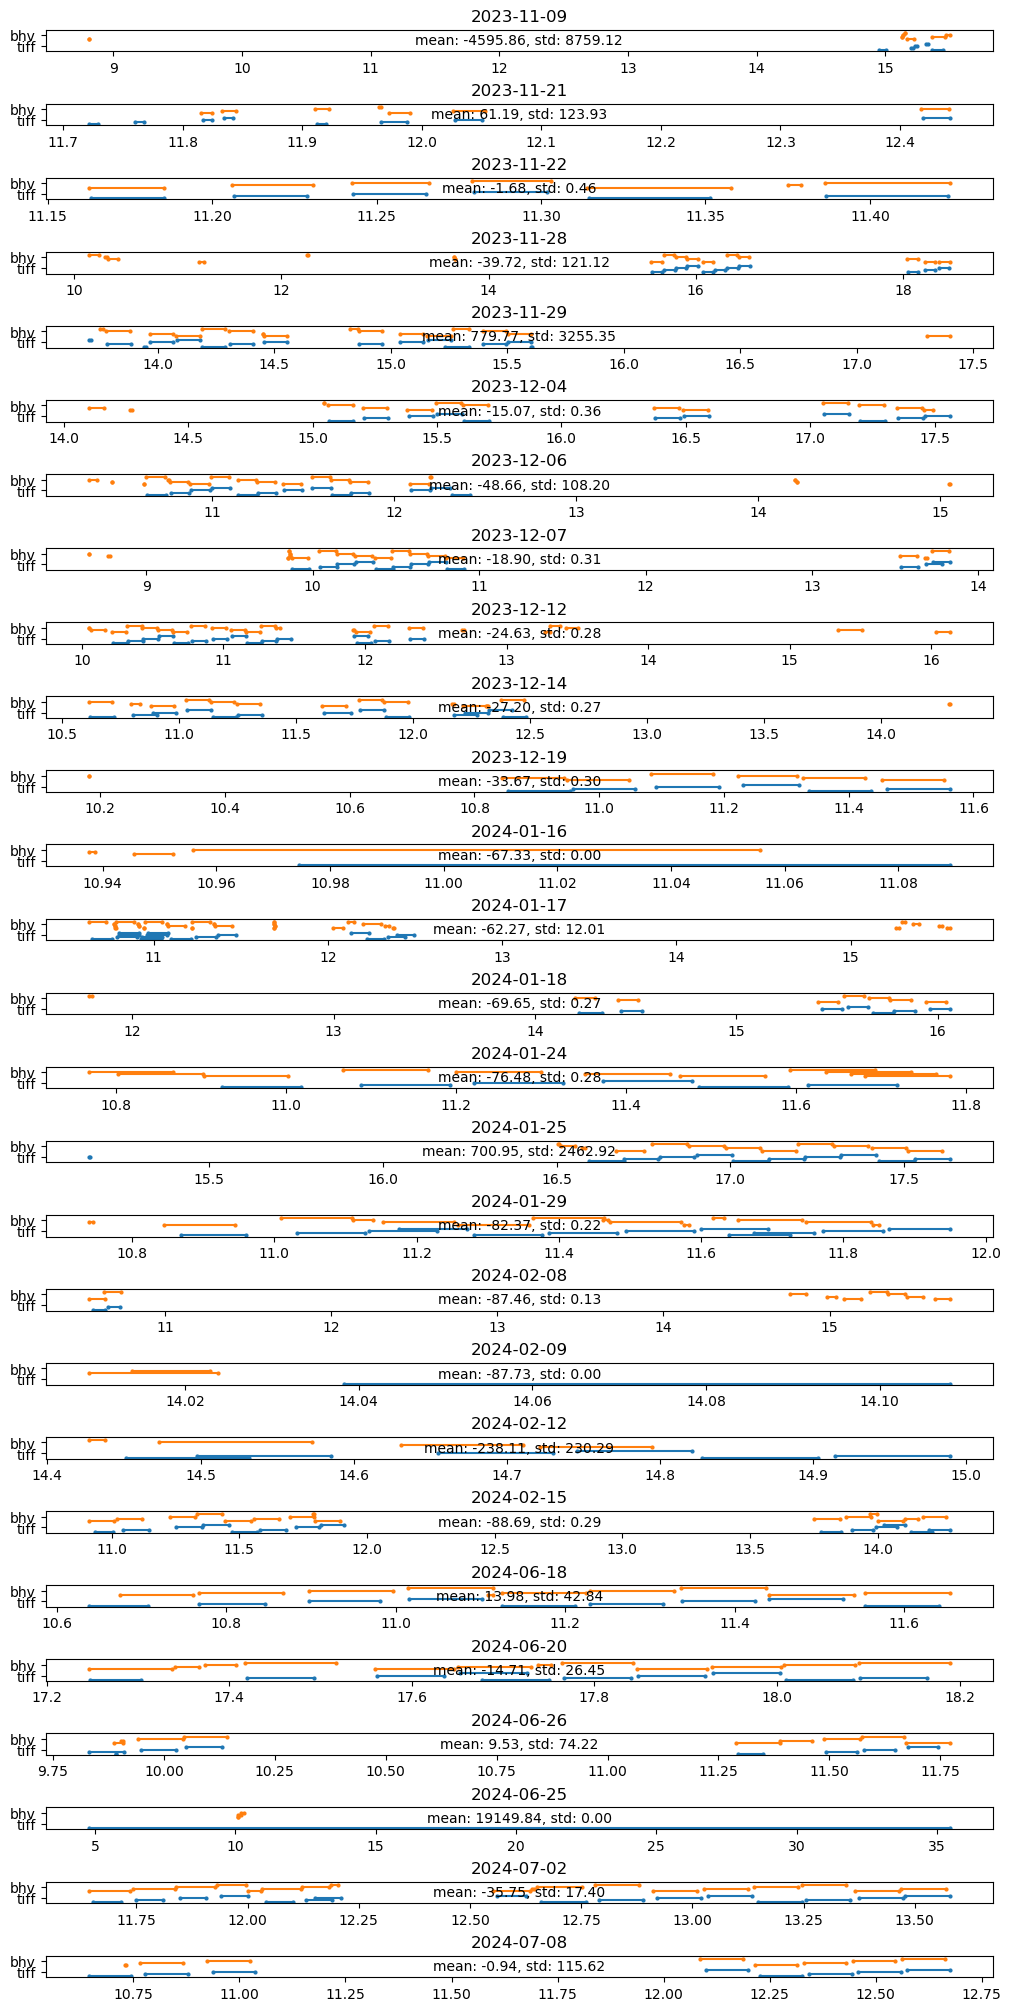

In [50]:
expt_dates = tiff_df['date'].unique()
fig, axs = plt.subplots(len(expt_dates), figsize=(10,20), layout="constrained")
for index, expt_date in enumerate(expt_dates):
    plot_expt_file_intervals(expt_date, tiff_df, bhv_df, axs[index])

In [51]:
# Is the delay for any given day the same?
# If so I can use that to align the tiff and behavioral data

### Check if the delay between tiff and bhv creation date is consistent during one recording session.

In [52]:
expt_date = date.fromisoformat("2024-01-17")
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

<Axes: title={'center': '2024-01-17'}>

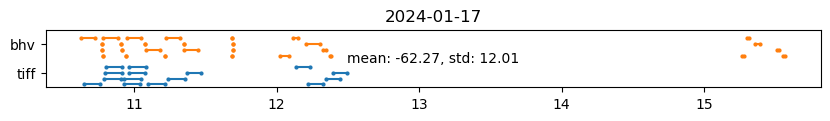

In [53]:
fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax)

In [54]:
tiff_df_subset

,path,tiff,datetime,date,interval,interval_sub_midnight
116,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:38:42.498617,2024-01-17,"(1705516722.498617, 1705517134.0355768)","[10.64513850470384, 10.759454326894549]"
117,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:47:25.439832,2024-01-17,"(1705517245.439832, 1705517656.967208)","[10.79039995332559, 10.904713113307954]"
118,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:47:56.261198,2024-01-17,"(1705517276.261198, 1705517687.800554)","[10.798961443901062, 10.91327793167697]"
119,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:48:09.728358,2024-01-17,"(1705517289.728358, 1705517701.28209)","[10.80270232167509, 10.917022802763515]"
120,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:55:34.193640,2024-01-17,"(1705517734.19364, 1705518145.752164)","[10.926164899998241, 11.04048671219084]"
121,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:55:51.876851,2024-01-17,"(1705517751.876851, 1705518163.437771)","[10.93107690307829, 11.04539938085609]"
122,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:57:45.268198,2024-01-17,"(1705517865.268198, 1705518276.850682)","[10.962574499448142, 11.076902967227829]"
123,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:57:58.152351,2024-01-17,"(1705517878.152351, 1705518289.713271)","[10.966153430806266, 11.080475908584067]"
124,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 11:05:56.550037,2024-01-17,"(1705518356.550037, 1705518768.106165)","[11.099041676918665, 11.213362823592291]"
125,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 11:14:25.605087,2024-01-17,"(1705518865.605087, 1705519277.187571)","[11.240445857511626, 11.354774325291316]"


In [55]:
bhv_df_subset

,path,datetime,date,interval,interval_sub_midnight
492,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 12:22:33,2024-01-17,"(1705522953.0, 1705522963.332656)","[12.375833333333333, 12.378703515529631]"
493,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 12:19:29,2024-01-17,"(1705522769.0, 1705522852.5497818)","[12.324722222222222, 12.347930494944254]"
494,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 12:12:12,2024-01-17,"(1705522332.0, 1705522691.2832642)","[12.203333333333335, 12.30313424004449]"
495,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 12:06:56,2024-01-17,"(1705522016.0, 1705522141.4146423)","[12.115555555555554, 12.150392956203884]"
496,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 12:01:34,2024-01-17,"(1705521694.0, 1705521904.470169)","[12.026111111111112, 12.084575046963161]"
497,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 11:41:38,2024-01-17,"(1705520498.0, 1705520499.1037273)","[11.693888888888889, 11.69419547981686]"
498,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 11:41:31,2024-01-17,"(1705520491.0, 1705520491.8354943)","[11.691944444444443, 11.69217652618885]"
499,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 11:41:22,2024-01-17,"(1705520482.0, 1705520483.5939164)","[11.689444444444444, 11.689887199004492]"
500,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 11:41:14,2024-01-17,"(1705520474.0, 1705520475.2320848)","[11.687222222222223, 11.687564467986425]"
501,Z:\Live Fly Imaging data\unity\raw data\Backup...,2024-01-17 11:21:01,2024-01-17,"(1705519261.0, 1705519620.256897)","[11.350277777777778, 11.450071360270183]"


In [56]:
min_diffs = []
for i, tiff_row in tiff_df_subset.iterrows():
    tiff_ts = tiff_row['datetime'].timestamp()
    min_diff = None
    for j, bhv_row in bhv_df_subset.iterrows():
        bhv_ts = bhv_row['datetime'].timestamp()
        diff = bhv_ts - tiff_ts
        if min_diff is None:
            min_diff = diff
        if diff > 0:
            continue
        if abs(diff) < abs(min_diff):
            min_diff = diff
            bhv_path = bhv_row['path']
    min_diffs.append(min_diff)

print(np.mean(min_diffs))
print(np.std(min_diffs))

-62.27406454086304
12.009611215621305


## Align behavior data to tiffs

(10.6, 12.55)

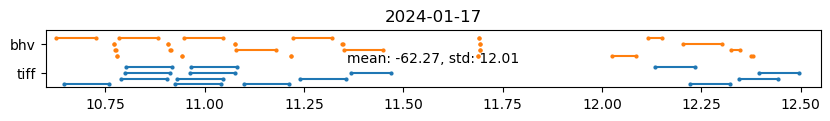

In [69]:
expt_date = date.fromisoformat("2024-01-17")

fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax)
ax.set_xlim(10.6, 12.55)

# Are recordings being canceled and restarted but tiffs still save metadata for full length??

In [58]:
df_dicts = []
tiff_intervals = tiff_df_subset['interval']
bhv_intervals = bhv_df_subset['interval']
for tiff_interval in tiff_intervals:
    for bhv_interval in bhv_intervals:
        # Shift bhv file start to tiffs starting point
        shift = tiff_interval[0] - bhv_interval[0]
        shifted_bhv_intervals = shift_intervals(bhv_intervals, shift)
        coverage = calculate_coverage(tiff_intervals, shifted_bhv_intervals)
        coverage_with_dup = calculate_coverage(tiff_intervals, shifted_bhv_intervals, with_duplicates=True)
        df_dicts.append({"shift": shift,
                         "coverage": coverage,
                         "coverage_with_dup": coverage_with_dup})

coverage_df = pd.DataFrame(df_dicts)

In [59]:
tiff_df_subset = tiff_df[tiff_df['date'] == expt_date]
bhv_df_subset = bhv_df[bhv_df['date'] == expt_date]

In [60]:
# tiff_df_subset.iloc[0].tiff.metadata
tiff_df_subset

,path,tiff,datetime,date,interval,interval_sub_midnight
116,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:38:42.498617,2024-01-17,"(1705516722.498617, 1705517134.0355768)","[10.64513850470384, 10.759454326894549]"
117,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:47:25.439832,2024-01-17,"(1705517245.439832, 1705517656.967208)","[10.79039995332559, 10.904713113307954]"
118,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:47:56.261198,2024-01-17,"(1705517276.261198, 1705517687.800554)","[10.798961443901062, 10.91327793167697]"
119,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:48:09.728358,2024-01-17,"(1705517289.728358, 1705517701.28209)","[10.80270232167509, 10.917022802763515]"
120,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:55:34.193640,2024-01-17,"(1705517734.19364, 1705518145.752164)","[10.926164899998241, 11.04048671219084]"
121,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:55:51.876851,2024-01-17,"(1705517751.876851, 1705518163.437771)","[10.93107690307829, 11.04539938085609]"
122,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:57:45.268198,2024-01-17,"(1705517865.268198, 1705518276.850682)","[10.962574499448142, 11.076902967227829]"
123,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 10:57:58.152351,2024-01-17,"(1705517878.152351, 1705518289.713271)","[10.966153430806266, 11.080475908584067]"
124,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 11:05:56.550037,2024-01-17,"(1705518356.550037, 1705518768.106165)","[11.099041676918665, 11.213362823592291]"
125,Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR...,<gulp2p.preproc.tiff.Tiff object at 0x000001D9...,2024-01-17 11:14:25.605087,2024-01-17,"(1705518865.605087, 1705519277.187571)","[11.240445857511626, 11.354774325291316]"


In [95]:
for i, tiff in enumerate(tiff_df_subset['tiff']):
    if i == 0:
        continue

    frame_rate = tiff.metadata['frame_rate']
    num_frames = tiff.metadata['SizeC'] * (tiff.metadata['SizeZ'] + tiff.metadata['num_fb_frames']) * tiff.metadata['SizeT']
    length = num_frames / frame_rate

    print(tiff.path)
    print(f"frame rate: {frame_rate}")
    print(f"frame interval: {tiff.metadata['frame_interval']}")
    print(f"num frames:{num_frames}")
    print(f"length:{length}")
    # print(f"imagej metadata{tiff.get_imagej_metadata()}")

    import tifffile as tf
    with tf.TiffFile(tiff.path) as tiff_file:
        print(len(tiff_file.pages))
    #     imagej_metadata = tiff_file.imagej_metadata
        for page in tiff_file.pages:
            print(page.axes)
            # for tag in page.tags:
            #     tag_name, tag_value = tag.name, tag.value
            #     print(f"{tag_name}: {tag_value}")
    #         break
    # print(imagej_metadata)

    break

Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00002.tif
frame rate: 58.222
frame interval: 0.0171756
num frames:26955
length:462.9693243103981
883
YX


AttributeError: 'TiffFile' object has no attribute 'axes'

In [61]:
for path in tiff_df_subset['path']:
    print(path)

Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00001.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00002.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00003.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00004.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00005.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00006.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00007.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00008.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00009.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00010.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly1_00011.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly2_00001.tif
Z:\2PImaging\Kerstin\MIMS\20240117\20240117_DR019xiGluSnFr_Fly2_00003.tif
Z:\2PImaging\Kerstin\MIMS\20240117\202

In [62]:
for path in bhv_df_subset['path']:
    print(path)

Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_12-22-33.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_12-19-29.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_12-12-12.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_12-06-56.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_12-01-34.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-41-38.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-41-31.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-41-22.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-41-14.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-21-01.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-20-49.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-13-17.json
Z:\Live Fly Imaging data\unity\raw data\Backups\Log_2024-01-17_11-13-05.json

best shift: 68.60508704185486
coverage: 0.4673852844293721


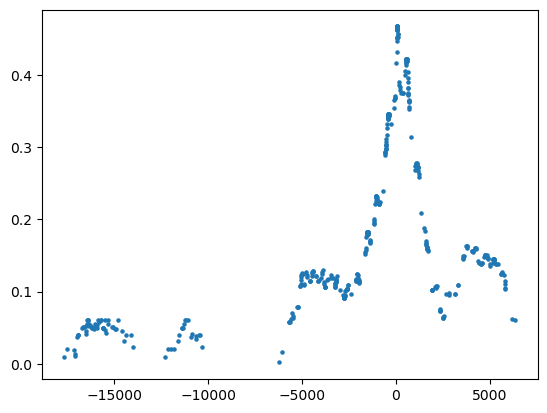

In [63]:
ax = plt.scatter(coverage_df['shift'], coverage_df['coverage'], s=5)
best_row = coverage_df.loc[coverage_df['coverage'].idxmax()]
print(f"best shift: {best_row['shift']}")
print(f"coverage: {best_row['coverage']}")
pass

In [64]:
coverage_df[coverage_df['coverage']>coverage_df['coverage'].quantile(0.90)].sort_values('coverage')

,shift,coverage,coverage_with_dup
164,529.876851,0.416643,0.684654
48,23.439832,0.416865,0.689405
301,532.353598,0.417899,0.688002
275,593.605087,0.419005,0.724574
52,591.439832,0.420096,0.725172
137,543.193640,0.420916,0.699757
165,543.876851,0.421036,0.700456
302,544.353598,0.421198,0.700939
247,546.550037,0.421569,0.702795
138,557.193640,0.422694,0.711427


In [65]:
coverage_df.describe()

,shift,coverage,coverage_with_dup
count,435.000000,435.000000,435.000000
mean,-2678.562717,0.185839,0.309759
std,6181.711318,0.131272,0.233008
min,-17666.501383,0.001746,0.001746
25%,-4343.039001,0.096608,0.111800
50%,-906.847649,0.138494,0.194346
75%,763.724191,0.275811,0.499183
max,6367.649480,0.467385,0.754881


In [66]:
# Get shift with max coverage
best_shift = coverage_df.loc[coverage_df['coverage'].idxmax(), "shift"]

In [67]:
best_shift

68.60508704185486

### Plot overlaps

(12.5, 12.8)

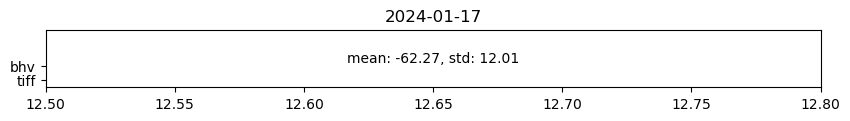

In [68]:
expt_date = date.fromisoformat("2024-01-17")

fig, ax = plt.subplots(figsize=(10,0.75))
plot_expt_file_intervals(expt_date, tiff_df, bhv_df, ax, with_overlaps=True)

ax.set_xlim([12.5, 12.8])